
# [Video RAG] 프레임 추출

---



In [1]:
%pip install opencv-python pillow -Uqqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 41.6 MB/s eta 0:00:00


In [2]:
# 구글 드라이브 마운트 및 연동
from google.colab import drive # Colab 에서 구글 드라이브 사용 모듈
drive.mount('/content/drive') # 현재 런타임에서 내 구글드라이브 마운트(연동)

BASE_PATH = '/content/drive/MyDrive/34기/05_multimodal_rag'

Mounted at /content/drive


In [3]:
from google.colab import userdata
import os

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')

## opencv
**OpenCV**는 "Open Source Computer Vision Library"의 약자로, **실시간 이미지 및 영상 처리**를 위한 오픈소스 라이브러리이다. 인텔에서 개발을 시작했으며, 현재는 다양한 운영체제(Windows, Linux, macOS, Android 등)와 프로그래밍 언어(Python, C++, Java 등)를 지원한다.

**Python에서 OpenCV**는 주로 `cv2` 패키지를 통해 사용하며, 이미지와 영상의 읽기, 쓰기, 변환, 필터링, 객체 인식 등 다양한 컴퓨터 비전 기능을 쉽게 구현할 수 있다.

- **이미지/영상 처리**: 이미지 읽기, 쓰기, 변환, 필터 적용, 색상 변환 등 기본적인 영상 처리 기능을 제공한다.
- **컴퓨터 비전 알고리즘**: 얼굴 인식, 객체 추적, 패턴 분석 등 고급 컴퓨터 비전 기술을 구현할 수 있다.
- **머신러닝 지원**: OpenCV에는 머신러닝 관련 함수도 내장되어 있어, 이미지 분류, 객체 검출 등에 활용할 수 있다.
- **빠른 처리 속도**: 실시간 처리를 위해 최적화되어 있으며, C++ 기반으로 개발되어 빠른 연산이 가능하다.
- **활용 분야**:
  - 얼굴 인식, 객체 추적, 자율주행, 공장 자동화, 의료 영상 분석 등 **다양한 실생활 문제 해결**에 활용된다.

In [4]:
!gdown 1zFdDejlTNGPSL5BVngJWTevOY2jipGrG

Downloading...
From: https://drive.google.com/uc?id=1zFdDejlTNGPSL5BVngJWTevOY2jipGrG
To: /content/image.jpg
100% 98.3k/98.3k [00:00<00:00, 3.44MB/s]


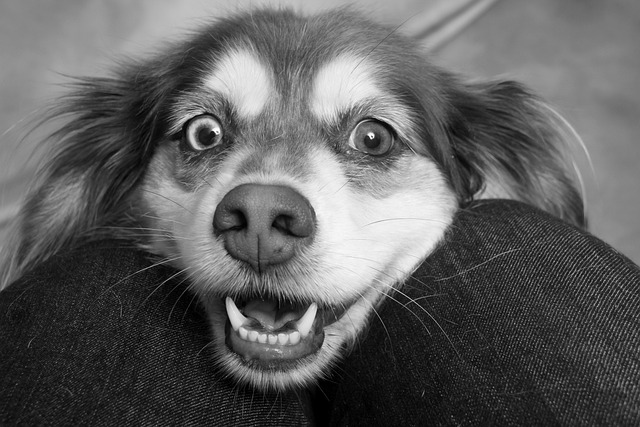

In [5]:
import cv2 # OpenCV : 이미지 입출력 / 처리
from google.colab.patches import cv2_imshow # Colab에서 OpenCV 이미지 출력

# colab에서 실행시
img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE) # 이미지를 흑백으로 읽기
cv2_imshow(img) # 이미지 표시

In [ ]:
# 로컬실행
# img = cv2.imread('image.jpg')
# cv2.imshow('img', img)
# cv2.waitkey(0) # 키보드입력 무한대기
# cv2.destroyAllWindows()

In [11]:
# Numpy + OpenCV 로 단색(빨강/검정/흰/초록/파랑) 생성 및 저장
import numpy as np
import cv2

# 검정색
black = np.zeros((300, 300, 3), dtype =np.uint8) # (H, W, C) 값을 0으로 채움
cv2.imwrite('black.png', black)

# 흰색
white = np.ones((300, 300, 3), dtype =np.uint8) * 255 # 1로 채운 값을 255로 곱해줌
cv2.imwrite('white.png', white)

# 빨강 : (B, G, R) 에서 R만 255
red = np.zeros((300, 300, 3), dtype =np.uint8)
red[:, :, 2] = 255
cv2.imwrite('red.png', red)

# 초록 : (B, G, R) 에서 G만 255
green = np.zeros((300, 300, 3), dtype =np.uint8)
green[:, :, 1] = 255
cv2.imwrite('green.png', green)

# 파랑 : (B, G, R) 에서 B만 255
blue = np.zeros((300, 300, 3), dtype =np.uint8)
blue[:, :, 0] = 255
cv2.imwrite('blue.png', blue)


True

### 동영상 재생
- cap.read(): colab 재생시 콘솔에 프레임 연속출력
- HTML태그 출력: 동영상 html태그를 통한 출력